# Notebook 1: Análise Exploratória de Dados (EDA) e Pré-Processamento
### Projeto Final de Licenciatura - Sistemas de Apoio à Decisão Clínica

**Autor:** Gustavo P. Vília  
**Âmbito:** Transparência em Sistemas de Apoio à Decisão Clínica: Impacto da Inteligência Artificial Explicável na Triagem Radiológica

---

## 🎯 Objetivo deste Notebook
O presente documento constitui a primeira fase prática da construção do artefacto tecnológico. O objetivo principal deste *notebook* é importar, analisar e preparar a base de dados (o *NIH Chest X-Ray Dataset*) para o posterior treino da rede neuronal. Devido à elevada volumetria dos dados originais (mais de 112 mil imagens radiográficas e ~42GB de tamanho), esta fase foca-se na otimização computacional e na filtragem estratégica.

## 📋 Etapas Principais:
1. **Configuração de Ambiente:** Ligação à API do Kaggle para extração direta e otimizada dos dados para a máquina virtual, contornando limitações de armazenamento local.
2. **Análise Exploratória (EDA):** Verificação estatística dos metadados clínicos e identificação visual do problema estrutural do conjunto de dados: o severo **desequilíbrio de classes** (*class imbalance*).
3. **Filtragem de Dados:** Delimitação do âmbito de classificação para Nódulos e Massas (com grupo de controlo saudável), de forma a garantir uma validação posterior fiável através do Grad-CAM.
4. **Pré-Processamento:** Preparação matemática das imagens (redimensionamento para 224x224 píxeis e normalização) e configuração dos geradores de *Data Augmentation*.

*Nota: O output final deste notebook será um conjunto de dados estruturado e limpo, pronto a ser ingerido pela arquitetura DenseNet121 no Notebook 2.*

## 1. Importação Otimizada do Dataset (KaggleHub)
Para colmatar as limitações de memória volátil (RAM e Disco) do ambiente Google Colab, optou-se por utilizar a biblioteca moderna kagglehub para a extração dos dados. Em vez de importar o dataset original com resolução de 1024x1024 píxeis (aproximadamente 42GB), importa-se uma versão do repositório já otimizada e pré-redimensionada para 224x224 píxeis. Esta decisão arquitetural permite acelerar drasticamente o tempo de I/O (Input/Output) e cumpre antecipadamente os requisitos de input da rede DenseNet121, reduzindo a sobrecarga computacional na fase de pré-processamento.

In [1]:
# 1. Instalar a biblioteca kagglehub (caso o Colab não tenha a versão mais recente)
!pip install -q kagglehub

import kagglehub
import os

# 2. Fazer o download do dataset pré-redimensionado (224x224)
print("A iniciar o download do dataset otimizado via KaggleHub...")
caminho_dataset = kagglehub.dataset_download("khanfashee/nih-chest-x-ray-14-224x224-resized")

print(f"\n✅ Download concluído com sucesso!")
print(f"📁 Os dados foram guardados no caminho temporário: {caminho_dataset}")

# 3. Listar os ficheiros que vieram lá dentro para confirmarmos o nome do CSV
print("\nConteúdo da pasta do dataset:")
print(os.listdir(caminho_dataset))

A iniciar o download do dataset otimizado via KaggleHub...


100%|██████████| 2.30G/2.30G [00:24<00:00, 100MB/s]

Extracting files...



✅ Download concluído com sucesso!
📁 Os dados foram guardados no caminho temporário: /root/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3

Conteúdo da pasta do dataset:
['images-224', 'Data_Entry_2017.csv', 'BBox_List_2017_Official_NIH.csv', 'train_val_list_NIH.txt', 'test_list_NIH.txt', 'pretrained_model.h5']


## 2. Análise Exploratória de Dados (EDA): Desequilíbrio de Classes

O passo seguinte incide na validação empírica do desequilíbrio estrutural inerente ao dataset NIH. Através da biblioteca Pandas, efetuamos a leitura do ficheiro de metadados (Data_Entry_2017.csv). Dado o caráter multirrótulo da base de dados (onde um único paciente pode apresentar doenças concomitantes separadas pelo delimitador |), implementamos um algoritmo de filtragem para contabilizar a frequência absoluta de cada patologia individual. O output visual desta análise um gráfico de barras ordenado materializa a justificação clínica para a posterior restrição do modelo às classes de Nódulo e Massa, conforme preconizado na metodologia do projeto.

Total de Raios-X lidos: 112120


/tmp/ipykernel_367/3548432005.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequência', y='Patologia', data=df_contagem, palette='magma')


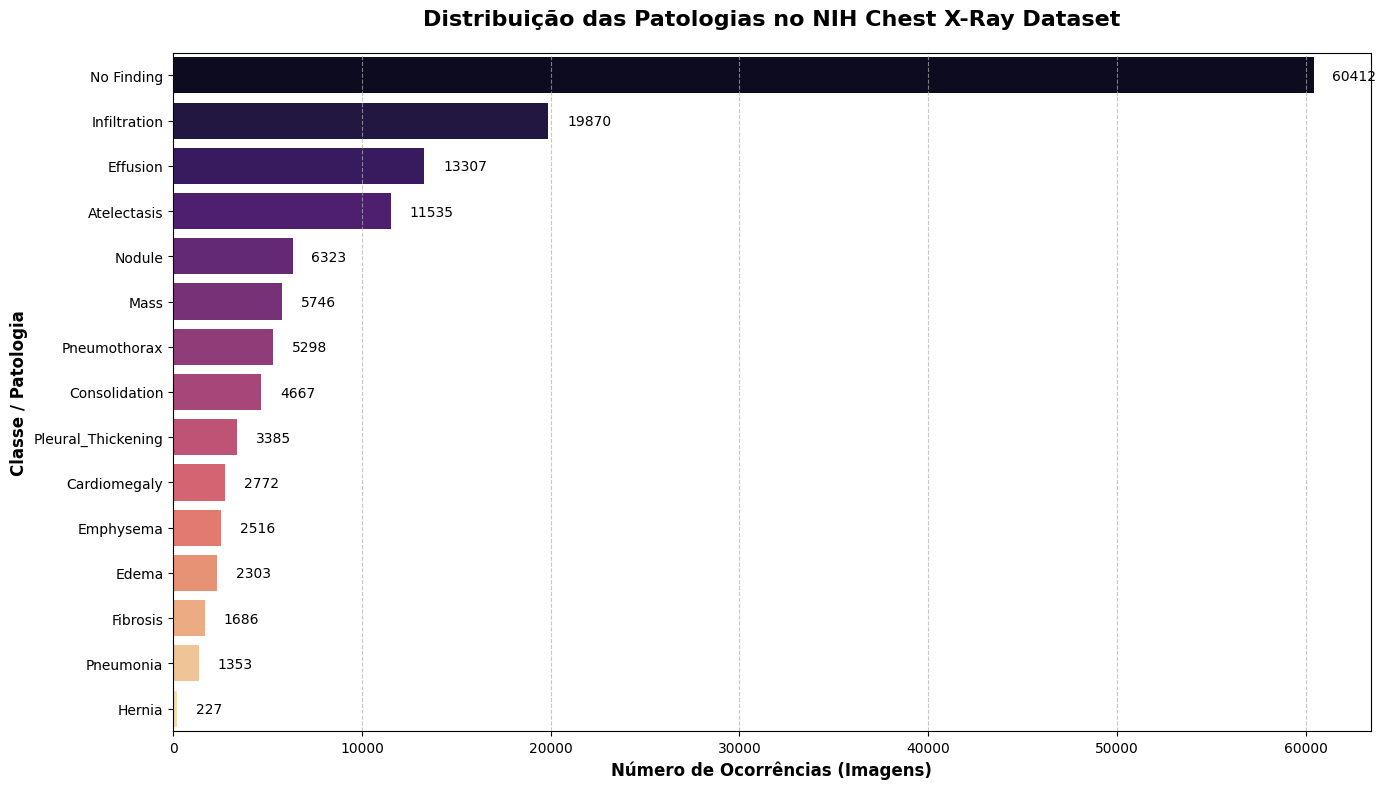

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# 1. Definir o caminho exato para o ficheiro CSV com base no download do Kagglehub
# Usamos a variável 'caminho_dataset' que criaste na célula anterior
caminho_csv = os.path.join(caminho_dataset, 'Data_Entry_2017.csv')

# Ler o ficheiro para a memória do Pandas
df = pd.read_csv(caminho_csv)
print(f"Total de Raios-X lidos: {len(df)}")

# 2. Processar a coluna 'Finding Labels'
# O lambda divide strings como "Nodule|Pneumonia" e o concatenate junta tudo
todas_labels = np.concatenate(df['Finding Labels'].apply(lambda x: x.split('|')).values)
contagem_doencas = Counter(todas_labels)

# 3. Preparar um DataFrame para facilitar a plotagem do gráfico
df_contagem = pd.DataFrame.from_dict(contagem_doencas, orient='index', columns=['Frequência']).reset_index()
df_contagem = df_contagem.rename(columns={'index': 'Patologia'}).sort_values(by='Frequência', ascending=False)

# 4. Gerar o Gráfico de Barras (Formatado para o Relatório)
plt.figure(figsize=(14, 8))
# Paleta de cores forte e profissional
sns.barplot(x='Frequência', y='Patologia', data=df_contagem, palette='magma')

# Títulos e labels de eixo
plt.title('Distribuição das Patologias no NIH Chest X-Ray Dataset', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Ocorrências (Imagens)', fontsize=12, fontweight='bold')
plt.ylabel('Classe / Patologia', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionar os números exatos à frente de cada barra
for i, v in enumerate(df_contagem['Frequência']):
    plt.text(v + 1000, i + 0.1, str(v), color='black', fontsize=10)

plt.tight_layout()
# Mostrar o gráfico final
plt.show()

## 3. Filtragem e Balanceamento do Dataset (Undersampling)

Comprovado o acentuado desequilíbrio das classes originais, esta etapa implementa o protocolo de mitigação definido na metodologia do projeto. Primeiramente, isolamos as duas categorias de interesse (radiografias estritamente saudáveis e radiografias com Nódulos ou Massas). De seguida, aplicamos uma técnica de Undersampling aleatório à classe maioritária ("No Finding"). Esta operação reduz o número de casos de controlo para corresponder exatamente ao número de casos patológicos detetados. O resultado é um subset de dados perfeitamente equilibrado (50/50), garantindo que a Rede Neuronal Convolucional não desenvolva um viés em direção à classe dominante, otimizando assim a Sensibilidade (taxa de verdadeiros positivos) do modelo final.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolar os casos estritamente saudáveis (Classe 0)
df_saudaveis = df[df['Finding Labels'] == 'No Finding'].copy()
df_saudaveis['Classe_Binaria'] = 0
df_saudaveis['Rotulo'] = 'Saudável'

# 2. Isolar os casos com Nódulos ou Massas (Classe 1)
df_doentes = df[df['Finding Labels'].str.contains('Nodule|Mass')].copy()
df_doentes['Classe_Binaria'] = 1
df_doentes['Rotulo'] = 'Nódulo/Massa'

print(f"Total de Saudáveis (Original): {len(df_saudaveis)}")
print(f"Total de Doentes (Original): {len(df_doentes)}")

# Juntar tudo num DataFrame base (Ainda desbalanceado, para podermos dividir por pacientes primeiro!)
df_base = pd.concat([df_saudaveis, df_doentes]).reset_index(drop=True)

print("\n[INFO] Os dados foram filtrados para as duas classes.")
print("[INFO] O balanceamento será aplicado EXCLUSIVAMENTE ao conjunto de treino na próxima etapa, cumprindo o protocolo clínico.")

Total de Saudáveis (Original): 60412
Total de Doentes (Original): 11175

[INFO] Os dados foram filtrados para as duas classes.
[INFO] O balanceamento será aplicado EXCLUSIVAMENTE ao conjunto de treino na próxima etapa, cumprindo o protocolo clínico.


/tmp/ipykernel_367/1419018535.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequência', y='Patologia', data=contagem_antes, palette='Blues_r')


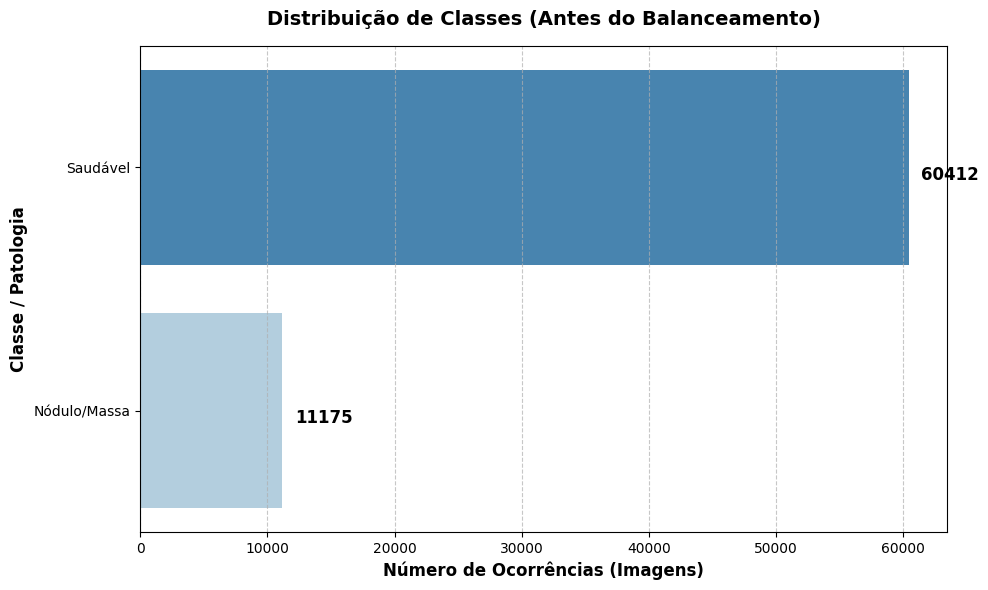

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem do dataset ANTES do balanceamento (usando o df_base que criámos no início)
contagem_antes = df_base['Rotulo'].value_counts().reset_index()
contagem_antes.columns = ['Patologia', 'Frequência']

# Gerar o Gráfico de Barras do "Antes"
plt.figure(figsize=(10, 6))
# Usamos uma cor diferente (ex: azuis) para o júri distinguir bem do gráfico final
sns.barplot(x='Frequência', y='Patologia', data=contagem_antes, palette='Blues_r')

plt.title('Distribuição de Classes (Antes do Balanceamento)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Ocorrências (Imagens)', fontsize=12, fontweight='bold')
plt.ylabel('Classe / Patologia', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionar os números exatos à frente de cada barra
for i, v in enumerate(contagem_antes['Frequência']):
    plt.text(v + 1000, i + 0.05, str(v), color='black', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Mapeamento de Diretórios e Divisão do Dataset (Holdout)

Com as classes rigorosamente balanceadas, o passo seguinte consiste em estabelecer a ponte entre os metadados tabulares e os ficheiros físicos das imagens. Para tal, constrói-se o caminho absoluto de cada radiografia através da coluna Image Index. De seguida, aplica-se a técnica de separação Holdout estruturada em 70% para Treino, 15% para Validação e 15% para Teste. É fundamental salientar o uso do parâmetro de estratificação (stratify), que assegura que a proporção perfeita de 50/50 entre classes saudáveis e patológicas seja escrupulosamente mantida em todos os subconjuntos gerados.

In [5]:
from sklearn.model_selection import train_test_split
import os

# 1. Mapear o caminho completo de cada imagem no disco do Colab
pasta_imagens = os.path.join(caminho_dataset, 'images-224', 'images-224')
df_base['Caminho_Imagem'] = df_base['Image Index'].apply(lambda x: os.path.join(pasta_imagens, x))

# Garantir que os rótulos são strings
df_base['Rotulo'] = df_base['Rotulo'].astype(str)

# ---------------------------------------------------------
# 2. DIVISÃO AO NÍVEL DO PACIENTE (Holdout 70/15/15)
# ---------------------------------------------------------
pacientes_unicos = df_base['Patient ID'].unique()

# Separar 15% dos pacientes para Teste
pacientes_treino_val, pacientes_teste = train_test_split(pacientes_unicos, test_size=0.15, random_state=42)

# Dos restantes, tirar a proporção para ficar com 15% para Validação (0.15 / 0.85 ≈ 0.1764)
pacientes_treino, pacientes_val = train_test_split(pacientes_treino_val, test_size=0.1764, random_state=42)

# Construir os subsets baseados nos IDs sorteados (Prevenção de Data Leakage!)
df_treino_desbalanceado = df_base[df_base['Patient ID'].isin(pacientes_treino)]
df_val = df_base[df_base['Patient ID'].isin(pacientes_val)]
df_teste = df_base[df_base['Patient ID'].isin(pacientes_teste)]

# ---------------------------------------------------------
# 3. BALANCEAMENTO APENAS NO CONJUNTO DE TREINO
# ---------------------------------------------------------
df_treino_doentes = df_treino_desbalanceado[df_treino_desbalanceado['Classe_Binaria'] == 1]
df_treino_saudaveis = df_treino_desbalanceado[df_treino_desbalanceado['Classe_Binaria'] == 0]

# Descobrir o menor número para equilibrar o treino
min_amostras = min(len(df_treino_doentes), len(df_treino_saudaveis))

# Reduzir a classe maioritária apenas no Treino (Undersampling)
df_treino_saudaveis_reduzido = df_treino_saudaveis.sample(n=min_amostras, random_state=42)
df_treino = pd.concat([df_treino_doentes, df_treino_saudaveis_reduzido]).sample(frac=1, random_state=42).reset_index(drop=True)

print("-" * 50)
print("📊 PROTOCOLO EXPERIMENTAL APLICADO COM SUCESSO:")
print("-" * 50)
print(f"Imagens de Treino (Balanceado 50/50): {len(df_treino)}")
print(f"Imagens de Validação (Desbalanceado - Mundo Real): {len(df_val)}")
print(f"Imagens de Teste (Desbalanceado - Mundo Real): {len(df_teste)}")

--------------------------------------------------
📊 PROTOCOLO EXPERIMENTAL APLICADO COM SUCESSO:
--------------------------------------------------
Imagens de Treino (Balanceado 50/50): 15980
Imagens de Validação (Desbalanceado - Mundo Real): 10414
Imagens de Teste (Desbalanceado - Mundo Real): 11098


/tmp/ipykernel_367/1139313558.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequência', y='Patologia', data=contagem_depois, palette='magma')


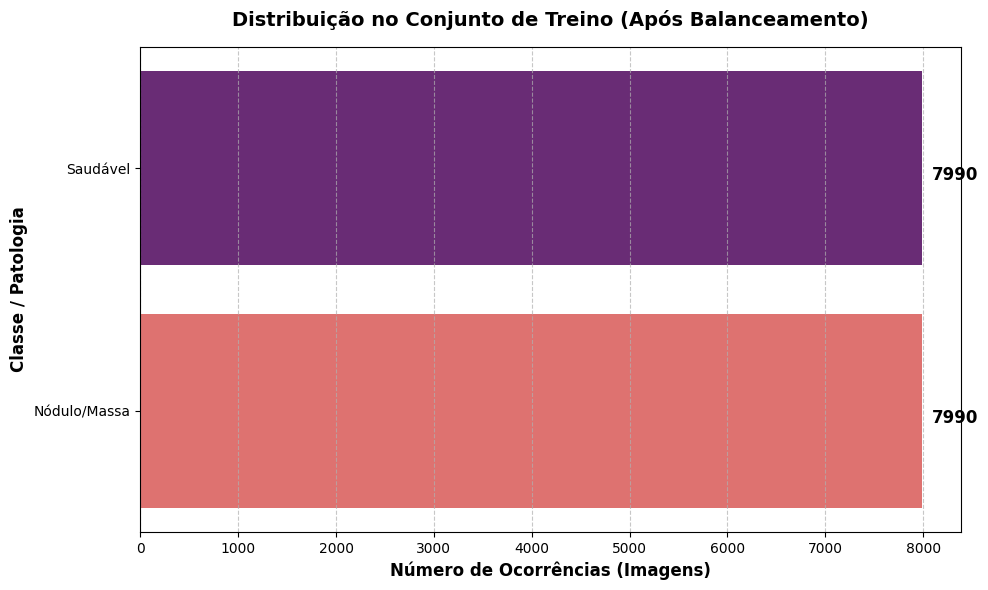

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar quantas imagens ficaram no conjunto de Treino após o balanceamento
contagem_depois = df_treino['Rotulo'].value_counts().reset_index()
contagem_depois.columns = ['Patologia', 'Frequência']

# Gerar o Gráfico de Barras do "Depois"
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequência', y='Patologia', data=contagem_depois, palette='magma')

plt.title('Distribuição no Conjunto de Treino (Após Balanceamento)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Ocorrências (Imagens)', fontsize=12, fontweight='bold')
plt.ylabel('Classe / Patologia', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionar os números exatos à frente de cada barra
for i, v in enumerate(contagem_depois['Frequência']):
    plt.text(v + 100, i + 0.05, str(v), color='black', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Pré-Processamento e Aumento de Dados (Data Augmentation)

A etapa final de preparação de dados consiste na instanciação dos geradores de imagem (ImageDataGenerator do Keras). O gerador de Treino é configurado com técnicas de Data Augmentation (rotação de 15 graus, ajustes de zoom e espelhamento horizontal) para introduzir variabilidade sintética e combater o overfitting. Em rigoroso cumprimento dos critérios anatómicos estabelecidos na metodologia, o espelhamento vertical é desativado. Adicionalmente, todos os geradores (Treino, Validação e Teste) aplicam uma normalização aos píxeis (rescale=1./255), comprimindo os valores de intensidade para o intervalo contínuo [0, 1]. Salienta-se que os conjuntos de Validação e Teste não sofrem qualquer alteração geométrica, garantindo que o modelo é avaliado com radiografias reais e inalteradas.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import files
import zipfile

# 1. Configurar os Geradores (As "fábricas" de imagens)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

TAMANHO_IMAGEM = (224, 224)
TAMANHO_LOTE = 32

print("A preparar o Gerador de Treino...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_treino,
    x_col='Caminho_Imagem',
    y_col='Rotulo',
    target_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    class_mode='binary'
)

print("\nA preparar o Gerador de Validação...")
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='Caminho_Imagem',
    y_col='Rotulo',
    target_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    class_mode='binary',
    shuffle=False
)

print("\nA preparar o Gerador de Teste...")
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_teste,
    x_col='Caminho_Imagem',
    y_col='Rotulo',
    target_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    class_mode='binary',
    shuffle=False
)

print("-" * 40)
print("✅ NOTEBOOK 1 CONCLUÍDO COM SUCESSO!")

# 3. Exportar os CSVs para a máquina local num ficheiro ZIP
print("\nA comprimir os dados limpos num ficheiro ZIP...")

# Guardar os CSVs temporariamente no disco do Colab
df_treino.to_csv('df_treino_limpo.csv', index=False)
df_val.to_csv('df_val_limpo.csv', index=False)
df_teste.to_csv('df_teste_limpo.csv', index=False)

# Criar o ficheiro ZIP
nome_zip = 'datasets_limpos_projeto.zip'
with zipfile.ZipFile(nome_zip, 'w') as zipf:
    zipf.write('df_treino_limpo.csv')
    zipf.write('df_val_limpo.csv')
    zipf.write('df_teste_limpo.csv')

print("A iniciar o download para o teu computador...")
files.download(nome_zip)

A preparar o Gerador de Treino...
Found 15980 validated image filenames belonging to 2 classes.

A preparar o Gerador de Validação...
Found 10414 validated image filenames belonging to 2 classes.

A preparar o Gerador de Teste...
Found 11098 validated image filenames belonging to 2 classes.
----------------------------------------
✅ NOTEBOOK 1 CONCLUÍDO COM SUCESSO!

A comprimir os dados limpos num ficheiro ZIP...
A iniciar o download para o teu computador...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>